# AIDS Clinical Trials Group Study 175 — ACTG175

## Chapters
0. Packages Importation and dataset uploading 
1. Introduction and Exploratory Data Analysis 
2. Survival Analysis: 

## 0. Packages Importation and dataset uploading

In [1]:

import pandas as pd  
import numpy as np           
import matplotlib.pyplot as plt   
import seaborn as sns       

from lifelines import KaplanMeierFitter, CoxPHFitter # Cox Model

from ucimlrepo import fetch_ucirepo 
df = fetch_ucirepo(id=890) 

X = df.data.features # Covariates
y = df.data.targets # Target

df = pd.concat([X, y], axis=1) 

## 1. Introduction and EDA

The **AIDS Clinical Trials Group (ACTG) Study 175 Dataset** contains clinical and demographic information on patients diagnosed with HIV/AIDS who participated in the ACTG 175 clinical trial. The study, whose results were published in 1996, was designed to evaluate the effectiveness of different antiretroviral treatment strategies and to investigate factors associated with disease progression and survival.

The dataset includes a combination of demographic characteristics, clinical measurements, treatment assignments, and outcome variables collected during the study. The variables are described below:
| Variable  | Description                                                      | Type                   |
| --------- | ---------------------------------------------------------------- | ------------------------- |
| `time`    | days to event or censoring                                       | `Surv()` time             |
| `cid`     | 1 = event (death/AIDS progression), 0 = censored                 | `Surv()` event            |
| `trt`     | treatment assignment (0=ZDV, 1=ZDV+ddI, 2=ZDV+Zal, 3=ddI)        | factor                    |
| `age`     | age at baseline (years)                                          | continuous covariate      |
| `wtkg`    | baseline weight (kg)                                             | continuous covariate      |
| `hemo`    | hemophilia status (0=no, 1=yes)                                  | binary covariate          |
| `homo`    | homosexual activity history (0=no, 1=yes)                        | binary covariate          |
| `drugs`   | history of intravenous drug use (0=no, 1=yes)                    | binary covariate          |
| `karnof`  | Karnofsky performance score (0–100)                              | continuous covariate      |
| `oprior`  | prior non-ZDV antiretroviral therapy (0=no, 1=yes)               | binary covariate          |
| `z30`     | ZDV use within 30 days before enrollment (0=no, 1=yes)           | binary covariate          |
| `zprior`  | prior ZDV use before enrollment (0=no, 1=yes)                    | binary covariate          |
| `preanti` | days of previous antiretroviral therapy                          | continuous covariate      |
| `race`    | race (0=white, 1=non-white)                                      | factor                    |
| `gender`  | sex (0=female, 1=male)                                           | factor                    |
| `str2`    | antiretroviral history stratum (0=naive, 1=experienced)          | factor                    |
| `symptom` | symptomatic status at baseline (0=no, 1=yes)                     | binary covariate          |
| `treat`   | grouped treatment indicator (0=ZDV only, 1=other therapies)      | factor                    |
| `offtrt`  | discontinued treatment before week 96 ± 5 (0=no, 1=yes)          | binary covariate          |
| `cd40`    | baseline CD4 cell count                                          | continuous covariate      |
| `cd420`   | CD4 cell count at week 20 ± 5                                    | continuous covariate      |
| `cd496`   | CD4 cell count at week 96 ± 5                                    | continuous covariate      |
| `cd80`    | baseline CD8 cell count                                          | continuous covariate      |
| `cd820`   | CD8 cell count at week 20 ± 5                                    | continuous covariate      |
| `pidnum`  | patient identifier                                               | ID, exclude from modeling |
| `strat`   | treatment stratification group                                   | factor                    |
| `r`       | indicator that week-96 CD4 count was observed (1) or missing (0) | missingness indicator     |

The dimensions of the dataset can be easily obtained by counting the number of observations (rows) and variables (columns). As shown below, the dataset contains **2139** observations and **24** variables, all described in the previous section.

In [2]:

print(df.shape) # Dimension check

(2139, 24)


After verifying that the dataset does not contain any missing values, we can proceed with the computation of descriptive statistics for each variable. These statistics provide an initial overview of the data distribution and help identify key characteristics, such as central tendency, variability, and the prevalence of different categories across the dataset.

In [3]:

missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values ✓")

Missing values:
No missing values ✓


In [4]:

df.describe().round(2)

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,cid
count,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,...,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00
mean,879.10,1.52,35.25,75.13,0.08,0.66,0.13,95.45,0.02,0.55,...,0.59,1.98,0.17,0.75,0.36,350.50,371.31,986.63,935.37,0.24
std,292.27,1.13,8.71,13.26,0.28,0.47,0.34,5.90,0.15,0.50,...,0.49,0.90,0.38,0.43,0.48,118.57,144.63,480.20,444.98,0.43
min,14.00,0.00,12.00,31.00,0.00,0.00,0.00,70.00,0.00,0.00,...,0.00,1.00,0.00,0.00,0.00,0.00,49.00,40.00,124.00,0.00
25%,727.00,1.00,29.00,66.68,0.00,0.00,0.00,90.00,0.00,0.00,...,0.00,1.00,0.00,1.00,0.00,263.50,269.00,654.00,631.50,0.00
50%,997.00,2.00,34.00,74.39,0.00,1.00,0.00,100.00,0.00,1.00,...,1.00,2.00,0.00,1.00,0.00,340.00,353.00,893.00,865.00,0.00
75%,1091.00,3.00,40.00,82.56,0.00,1.00,0.00,100.00,0.00,1.00,...,1.00,3.00,0.00,1.00,1.00,423.00,460.00,1207.00,1146.50,0.00
max,1231.00,3.00,70.00,159.94,1.00,1.00,1.00,100.00,1.00,1.00,...,1.00,3.00,1.00,1.00,1.00,1199.00,1119.00,5011.00,6035.00,1.00


Focusing on the censoring status of the observations, the previous table shows that 24.4% of the data are censored (variable cid). The censoring mechanism is *left-censoring*, meaning that the event of interest occurred before the observation time, but its exact occurrence time is unknown. Consequently, only an upper bound on the event time is available for these observations.

We can then proceed to rappresent the distribution of the treatments:

In [5]:

trt_map = {0: 'ZDV only', 1: 'ZDV+ddI', 2: 'ZDV+Zal', 3: 'ddI only'}
counts = df['trt'].value_counts().sort_index()
counts.index = counts.index.map(trt_map)
print(counts)

trt
ZDV only    532
ZDV+ddI     522
ZDV+Zal     524
ddI only    561
Name: count, dtype: int64


The dataset includes 2.139 HIV-positive patients enrolled in a clinical trial comparing four antiretroviral regimens: ZDV monotherapy (532), ZDV+ddI (522), ZDV+Zal (524), and ddI monotherapy (561). All three drugs (**Zidovudine, Didanosine, Zalcitabine**) belong to the NRTI class, the first generation of antiretroviral agents available in the early 1990s. The study, published in the New England Journal of Medicine in 1996, was designed to assess whether combination therapy offered a survival advantage over monotherapy, a question that ultimately shaped the modern standard of care for HIV treatment. The four treatment groups are well balanced in size, supporting the comparability of between-group analyses.

After assuring that, we can proceed to rappresent the histograms of the continuos variables:

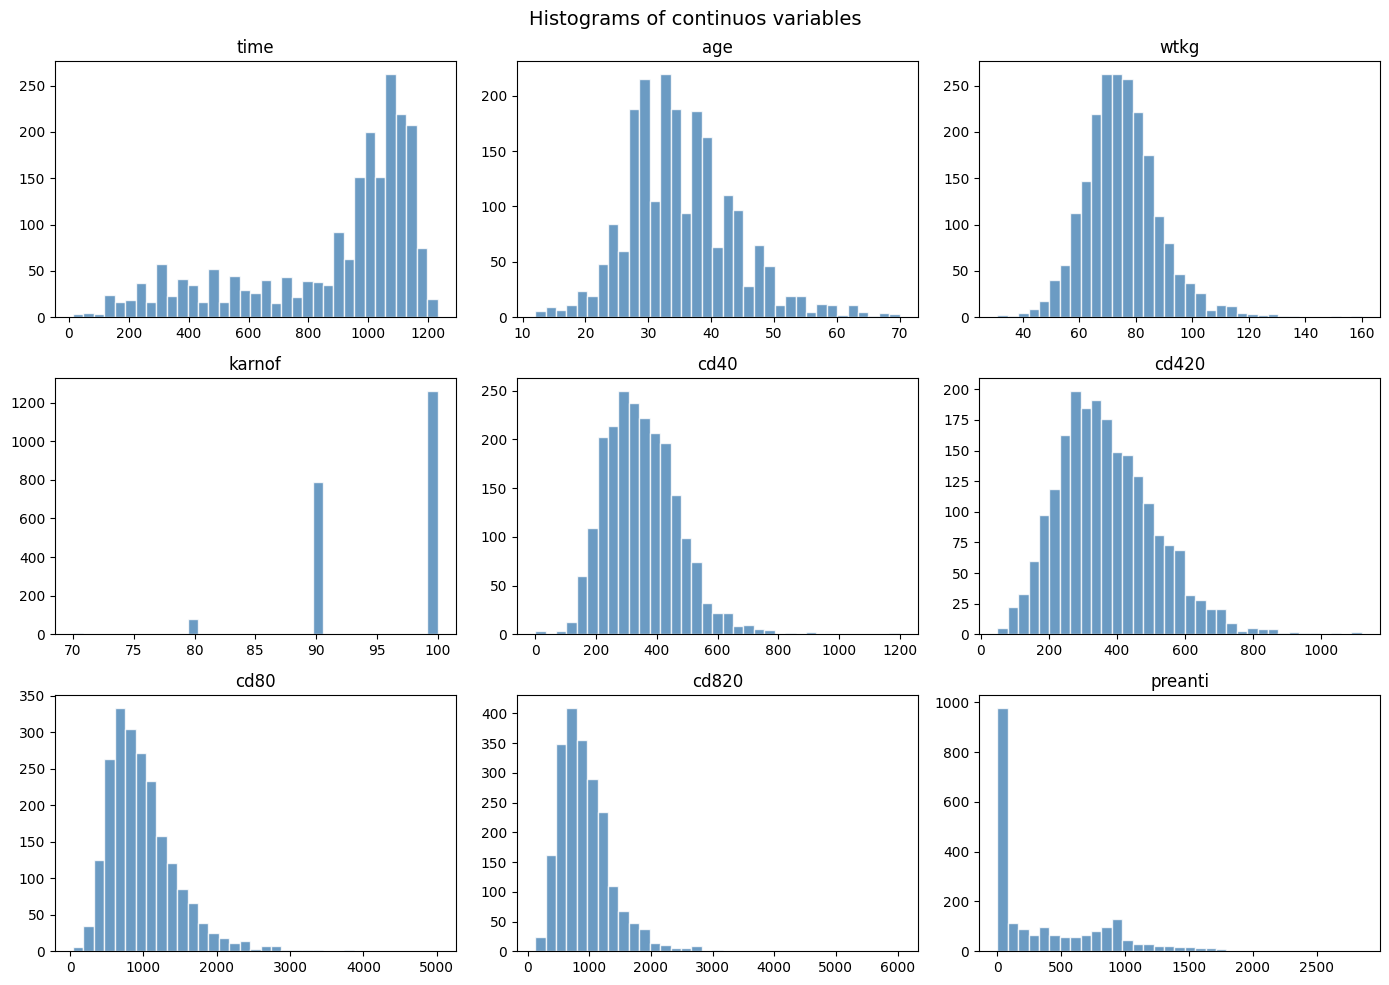

In [6]:

cont_vars = ['time', 'age', 'wtkg', 'karnof', 'cd40', 'cd420', 'cd80', 'cd820', 'preanti']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, var in zip(axes, cont_vars):
    ax.hist(df[var], bins=35, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(var)
    ax.set_xlabel('')

plt.suptitle('Histograms of continuos variables', fontsize=14)
plt.tight_layout()
plt.show()

We now focus on the relationship between treatment assignment and the outcome variable. As shown in the plots, combined therapy regimens tend to be associated with longer survival times and lower event rates compared to monotherapy. This is historically consistent with the advent of **HAART** (Highly Active Antiretroviral Therapy) in 1996, which established multi-drug combinations as the standard of care for HIV/AIDS and remains so today.

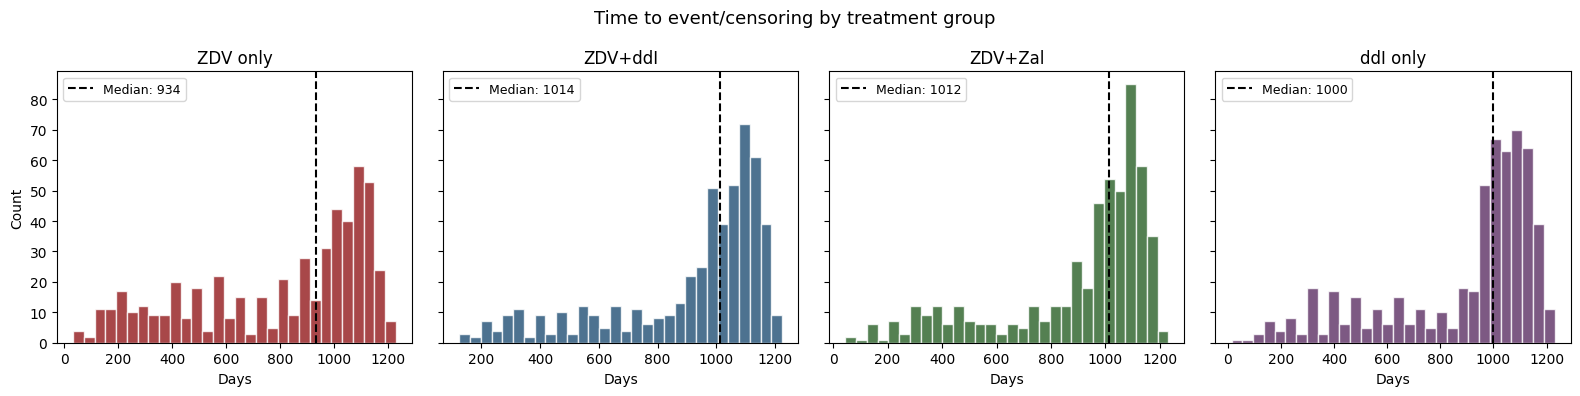

In [7]:

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

colors = ["#92191b", "#214f74", "#296127", "#5d2f64"]
trt_labels = {0: 'ZDV only', 1: 'ZDV+ddI', 2: 'ZDV+Zal', 3: 'ddI only'}

for ax, (trt_val, color) in zip(axes, zip([0,1,2,3], colors)):
    subset = df[df['trt'] == trt_val]['time']
    ax.hist(subset, bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(trt_labels[trt_val])
    ax.set_xlabel('Days')
    ax.axvline(subset.median(), color='black', linestyle='--', linewidth=1.5, label=f'Median: {subset.median():.0f}')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Count')
plt.suptitle('Time to event/censoring by treatment group', fontsize=13)
plt.tight_layout()
plt.show()

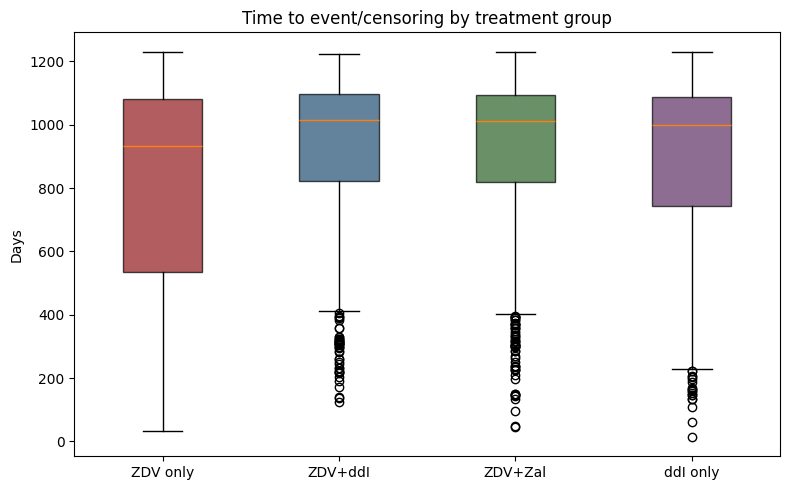

In [8]:

fig, ax = plt.subplots(figsize=(8, 5))

data_by_trt = [df[df['trt'] == t]['time'] for t in [0,1,2,3]]
bp = ax.boxplot(data_by_trt, tick_labels=trt_labels.values(), patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Days')
ax.set_title('Time to event/censoring by treatment group')
plt.tight_layout()
plt.show()

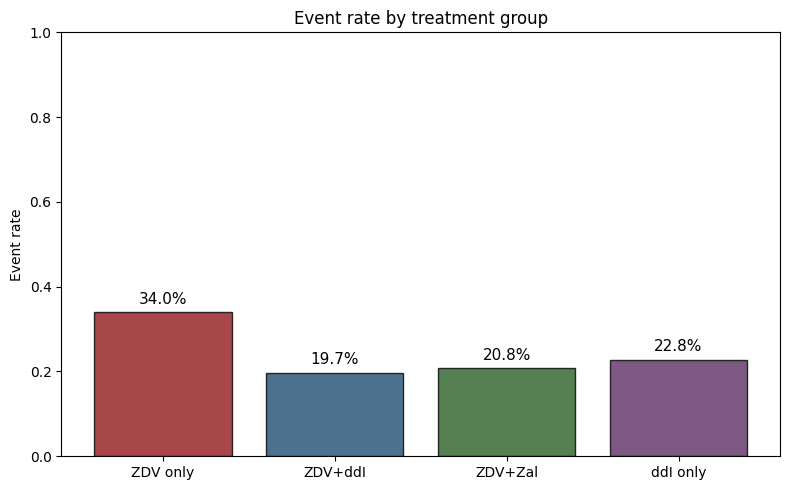

In [9]:

fig, ax = plt.subplots(figsize=(8, 5))

event_rate = df.groupby('trt')['cid'].mean()
ax.bar(trt_labels.values(), event_rate.values, color=colors, alpha=0.8, edgecolor='black')
ax.set_ylabel('Event rate')
ax.set_title('Event rate by treatment group')
ax.set_ylim(0, 1)
for i, v in enumerate(event_rate.values):
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

We then examine the correlation matrix among continuous variables. Most covariates show weak to moderate correlations, with no major multicollinearity concerns. The only notable relationship is the strong positive correlation between **cd80** and **cd820**, representing CD8 cell counts at baseline and at 20 weeks respectively. CD8 cells, also known as *cytotoxic T lymphocytes*, are immune cells responsible for destroying virus-infected cells. Unlike **CD4** cells (*T helper lymphocytes*), which are the primary target of HIV and progressively depleted as the disease advances, CD8 cells are not directly attacked by the virus and therefore remain relatively stable over time. This biological stability explains why a patient with high CD8 at baseline is likely to maintain elevated levels 20 weeks later, regardless of treatment arm.

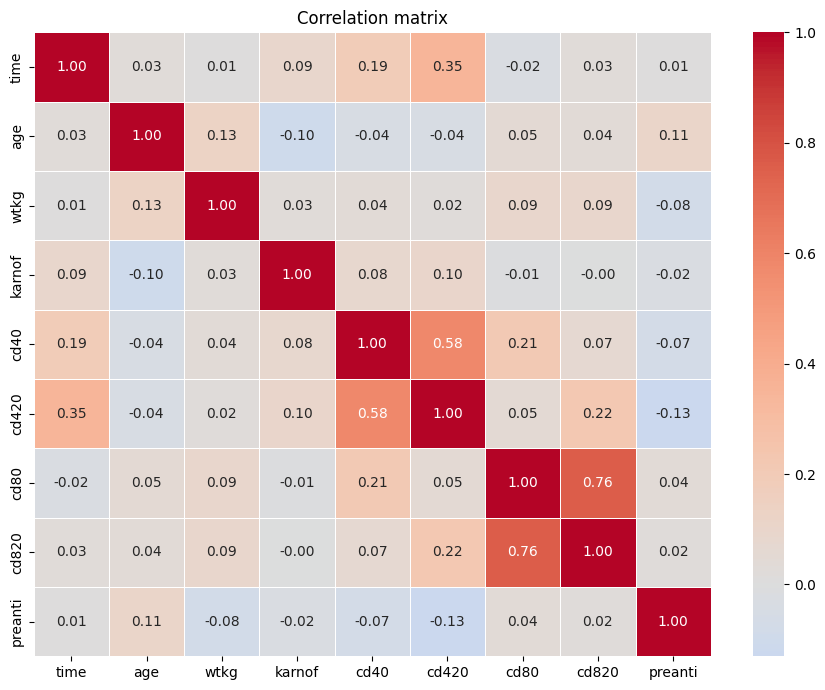

In [10]:

import seaborn as sns

cont_cols = ['time','age', 'wtkg', 'karnof', 'cd40', 'cd420', 'cd80', 'cd820', 'preanti']

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[cont_cols].corr().round(2), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()